#### Week2 10.6

### Beef Consumption for the world

-----

Workflow:

1. Previous exploration update;
2. Plot and analyze based on grouped value;
3. More data sources;

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [9]:
df = pd.read_csv('beef.csv')
df_shortened = df.drop(['Year Code', 'Note'], axis=1)
df_shortened

,Domain Code,Domain,Area Code (FAO),Area,Element Code,Element,Item Code (FBS),Item,Year,Unit,Value,Flag,Flag Description
0,FBS,Food Balances (2010-),5000,World,645,Food supply quantity (kg/capita/yr),S2731,Bovine Meat,2010,kg/cap,9.42,E,Estimated value
1,FBS,Food Balances (2010-),5000,World,645,Food supply quantity (kg/capita/yr),S2731,Bovine Meat,2011,kg/cap,9.21,E,Estimated value
2,FBS,Food Balances (2010-),5000,World,645,Food supply quantity (kg/capita/yr),S2731,Bovine Meat,2012,kg/cap,9.16,E,Estimated value
3,FBS,Food Balances (2010-),5000,World,645,Food supply quantity (kg/capita/yr),S2731,Bovine Meat,2013,kg/cap,9.15,E,Estimated value
4,FBS,Food Balances (2010-),5000,World,645,Food supply quantity (kg/capita/yr),S2731,Bovine Meat,2014,kg/cap,9.09,E,Estimated value
5,FBS,Food Balances (2010-),5000,World,645,Food supply quantity (kg/capita/yr),S2731,Bovine Meat,2015,kg/cap,8.94,E,Estimated value
6,FBS,Food Balances (2010-),5000,World,645,Food supply quantity (kg/capita/yr),S2731,Bovine Meat,2016,kg/cap,8.87,E,Estimated value
7,FBS,Food Balances (2010-),5000,World,645,Food supply quantity (kg/capita/yr),S2731,Bovine Meat,2017,kg/cap,8.91,E,Estimated value
8,FBS,Food Balances (2010-),5000,World,645,Food supply quantity (kg/capita/yr),S2731,Bovine Meat,2018,kg/cap,9.09,E,Estimated value
9,FBS,Food Balances (2010-),5000,World,645,Food supply quantity (kg/capita/yr),S2731,Bovine Meat,2019,kg/cap,9.13,E,Estimated value


Text(0, 0.5, 'Beef Consumption Quantity in kg/capita/yr')

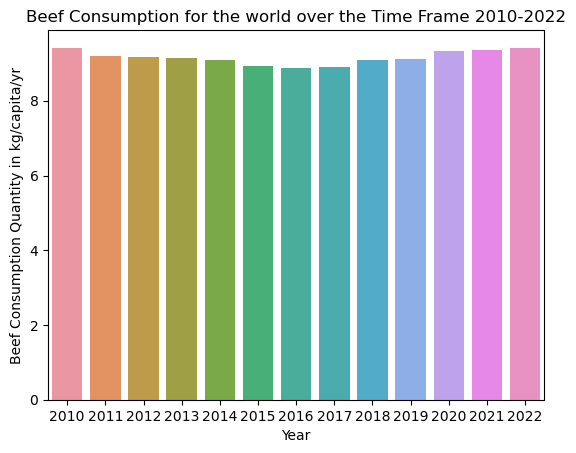

In [10]:
sns.barplot(x = 'Year', y = 'Value',data = df)
plt.title('Beef Consumption for the world over the Time Frame 2010-2022')
plt.ylabel('Beef Consumption Quantity in kg/capita/yr')

##### Note:

No obvious changes at the world level. Relatively stable change. The difference is not significant on the world level.

In [12]:
df2 = pd.read_csv('beef2.csv')
df_shortened_2 = df2.drop(['Year Code', 'Note','Domain Code', 'Domain', 'Element Code', 'Flag', 'Item Code (FBS)', 'Flag Description'],axis=1)
df_shortened_2

,Area Code (ISO3),Area,Element,Item,Year,Unit,Value
0,AFG,Afghanistan,Food supply quantity (kg/capita/yr),Bovine Meat,2010,kg/cap,4.74
1,AFG,Afghanistan,Food supply quantity (kg/capita/yr),Bovine Meat,2011,kg/cap,4.80
2,AFG,Afghanistan,Food supply quantity (kg/capita/yr),Bovine Meat,2012,kg/cap,4.40
3,AFG,Afghanistan,Food supply quantity (kg/capita/yr),Bovine Meat,2013,kg/cap,4.18
4,AFG,Afghanistan,Food supply quantity (kg/capita/yr),Bovine Meat,2014,kg/cap,4.99
...,...,...,...,...,...,...,...
2377,ZWE,Zimbabwe,Food supply quantity (kg/capita/yr),Bovine Meat,2018,kg/cap,40.99
2378,ZWE,Zimbabwe,Food supply quantity (kg/capita/yr),Bovine Meat,2019,kg/cap,40.98
2379,ZWE,Zimbabwe,Food supply quantity (kg/capita/yr),Bovine Meat,2020,kg/cap,40.12
2380,ZWE,Zimbabwe,Food supply quantity (kg/capita/yr),Bovine Meat,2021,kg/cap,43.77


In [13]:
df_area = df2.groupby('Area')[['Value']].agg(np.mean)
df_area2 = df_area.sort_values(by=['Value'])
df_area_2 = df_area2.reset_index()
df_area_2

/var/folders/jv/c17q5np950ncp50mdxmddd7r0000gn/T/ipykernel_47425/51684518.py:1: FutureWarning: The provided callable <function mean at 0x11063cea0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df_area = df2.groupby('Area')[['Value']].agg(np.mean)


,Area,Value
0,Democratic Republic of the Congo,0.284615
1,Mozambique,0.646923
2,Liberia,0.728462
3,Democratic People's Republic of Korea,0.892222
4,Burundi,1.090769
...,...,...
185,Australia,32.810769
186,United States of America,36.931538
187,Brazil,37.229231
188,Zimbabwe,45.130000


#### Divide countries into 5 groups each 
Very low: 0 - 5

low: 6 - 10

medium: 11 - 20

high: 21 - 30

very high: 31 - 51


In [15]:
very_low_df2 = df_area_2[df_area_2['Value'] <=5]
very_low_df2_countries = very_low_df2['Area'].values

low_df2 = df_area_2[(df_area_2['Value'] <=10) &(df_area_2['Value'] >=6)] 
low_df2_countries = low_df2['Area'].values

medium_df2 = df_area_2[(df_area_2['Value'] <=20) &(df_area_2['Value'] >=11)] 
medium_df2_countries = medium_df2['Area'].values

high_df2 = df_area_2[(df_area_2['Value'] <=30) &(df_area_2['Value'] >=21)] 
high_df2_countries = high_df2['Area'].values

very_high_df2 = df_area_2[(df_area_2['Value'] <=51) &(df_area_2['Value'] >=31)] 
very_high_df2_countries = very_high_df2['Area'].values


In [16]:
very_low_df2_countries

array(['Democratic Republic of the Congo', 'Mozambique', 'Liberia',
       "Democratic People's Republic of Korea", 'Burundi', 'Togo',
       'Papua New Guinea', 'Ghana', 'Bangladesh', 'Sri Lanka', 'India',
       'Poland', "Côte d'Ivoire", 'Sierra Leone', 'Madagascar',
       'Timor-Leste', 'Nigeria', 'Thailand', 'Sao Tome and Principe',
       'Republic of Moldova', 'Lesotho', 'Cabo Verde', 'Malawi',
       'Indonesia', 'Nicaragua', 'Rwanda', 'Congo', 'Gambia', 'Niger',
       'Yemen', 'Syrian Arab Republic', 'Benin', 'Iraq', 'Guyana',
       'Solomon Islands', 'Afghanistan', 'Ethiopia', 'Bulgaria', 'Fiji',
       'Guinea-Bissau', 'Viet Nam', 'Cameroon', 'Somalia', 'Libya',
       'Philippines', 'Kiribati', 'Cambodia', 'Belize', 'Peru', 'Haiti',
       'Lithuania', 'Uganda', 'Jamaica'], dtype=object)

In [17]:
G1 = df_shortened_2[df_shortened_2['Area'].isin(very_low_df2_countries)]
G2 = df_shortened_2[df_shortened_2['Area'].isin(low_df2_countries)]
G3 = df_shortened_2[df_shortened_2['Area'].isin(medium_df2_countries)]
G4 = df_shortened_2[df_shortened_2['Area'].isin(high_df2_countries)]
G5 = df_shortened_2[df_shortened_2['Area'].isin(very_high_df2_countries)]


In [18]:
dfG1 = G1.pivot_table(index=['Year'], columns = ['Area'],
                       values=['Value'], aggfunc = 'mean')
dfG2 = G2.pivot_table(index=['Year'], columns = ['Area'],
                       values=['Value'], aggfunc = 'mean')
dfG3 = G3.pivot_table(index=['Year'], columns = ['Area'],
                       values=['Value'], aggfunc = 'mean')
dfG4 = G4.pivot_table(index=['Year'], columns = ['Area'],
                       values=['Value'], aggfunc = 'mean')
dfG5 = G5.pivot_table(index=['Year'], columns = ['Area'],
                       values=['Value'], aggfunc = 'mean')

### 1. Group countries consumption quantity

Very low average consumption level countries:

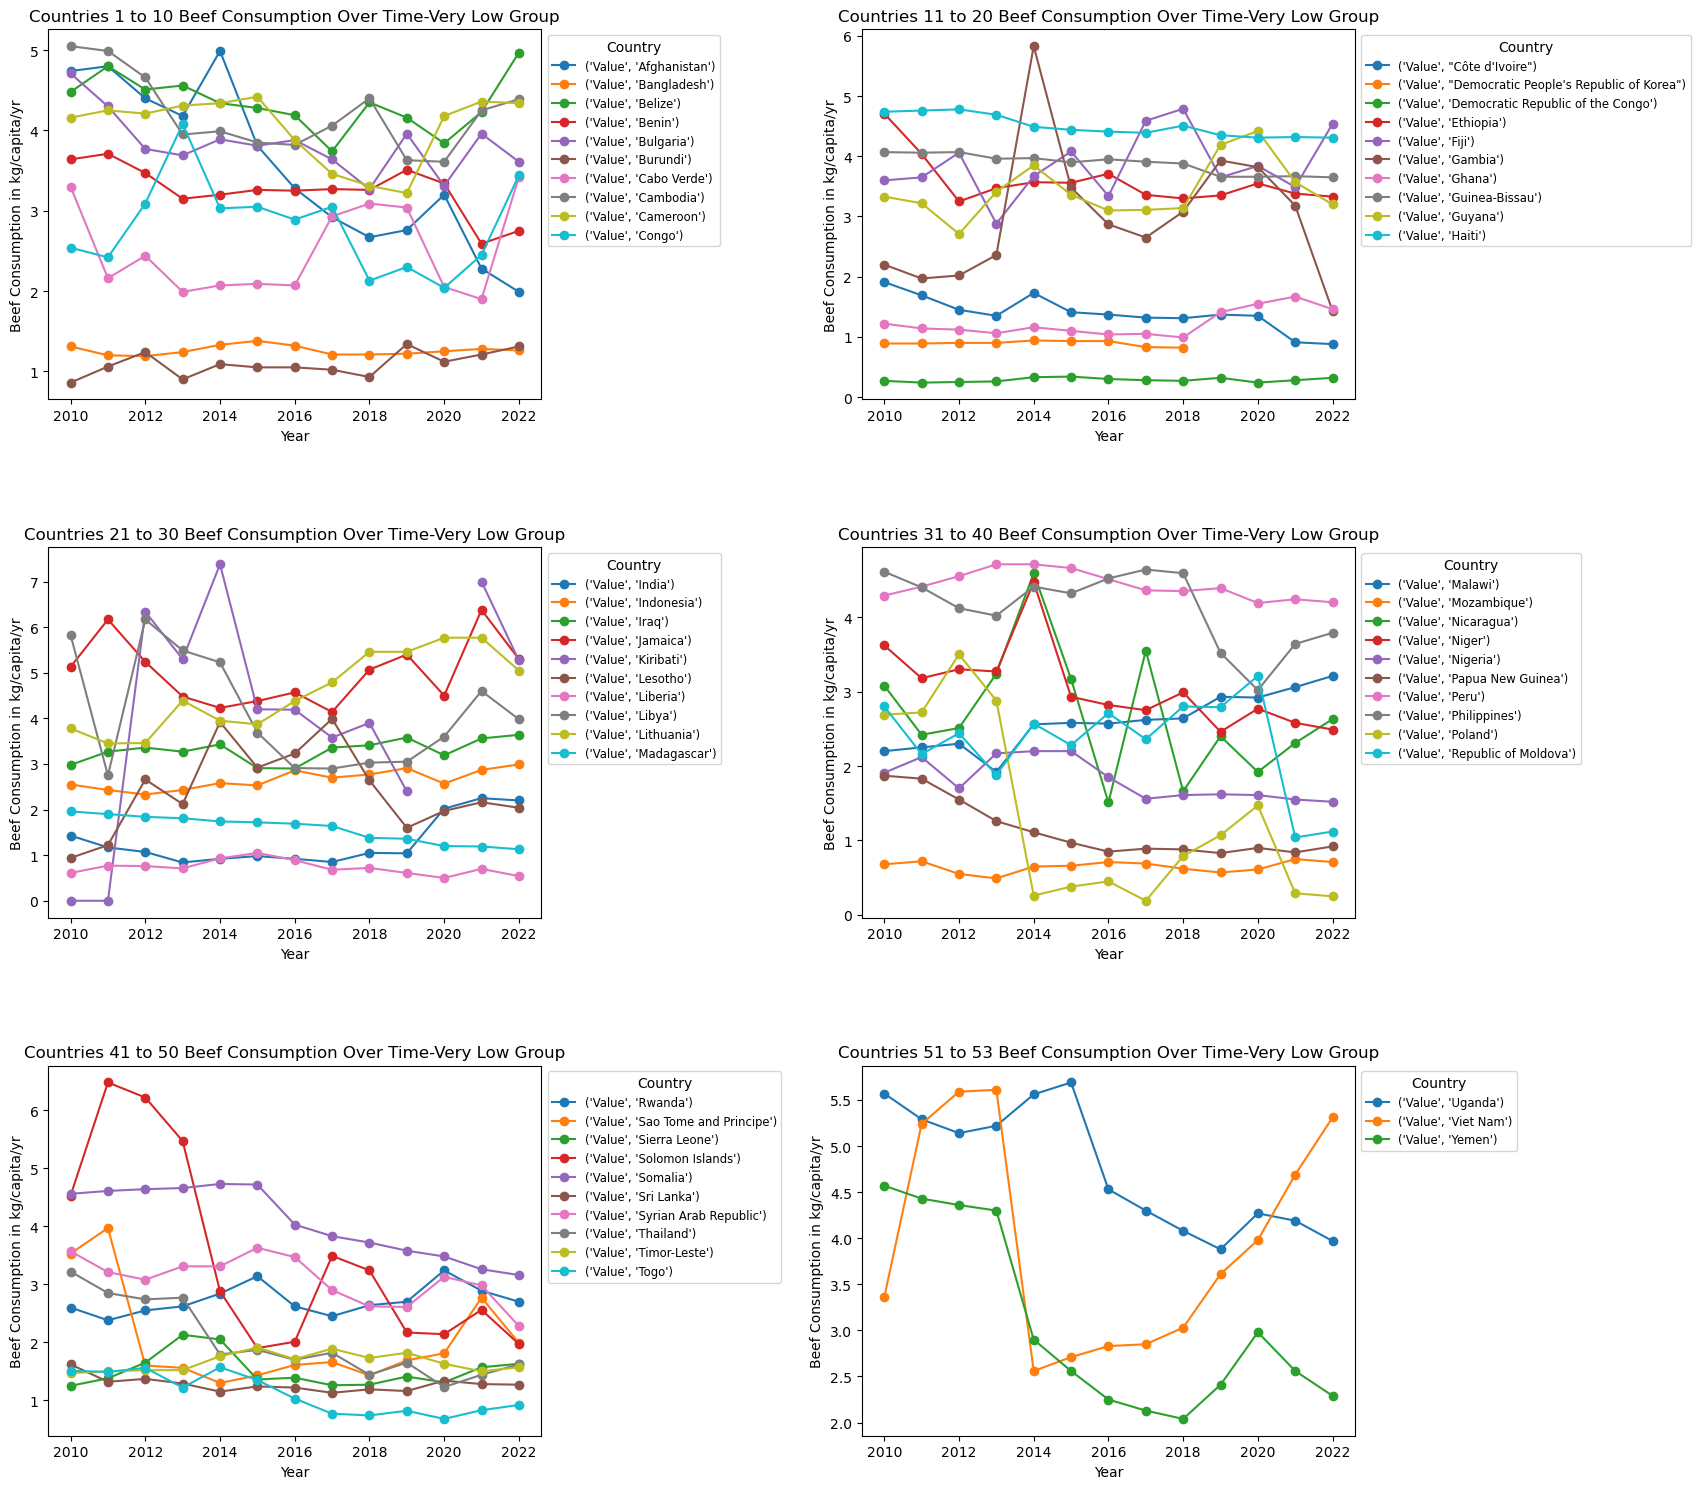

In [40]:
countries = dfG1.columns  
#data = {country: [i * j for j in range(1, len(years) + 1)] for i, country in enumerate(countries, 1)}

# How many rows and columns for subplots do I need?
num_plots = len(countries) // 10 + (1 if len(countries) % 10 != 0 else 0)
rows = (num_plots // 2) + (num_plots % 2)
cols = 2

# Increased figure size
fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 5))
axes = axes.flatten()

for i in range(0, len(countries), 10):
    selected_countries = countries[i:i+10]
    ax = axes[i // 10]  # Select the correct subplot ??
    
    for country in selected_countries:
        ax.plot(dfG1.index, dfG1[country], marker="o", label=country)
        
    ax.legend(title='Country', bbox_to_anchor=(1.001, 1), loc='upper left', fontsize='small')
    ax.set_title(f'Countries {i+1} to {min(i+10, len(countries))} Beef Consumption Over Time-Very Low Group')
    ax.set_xlabel('Year')
    ax.set_ylabel('Beef Consumption in kg/capita/yr')

# Hide any unused subplots
for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.subplots_adjust(right=0.85, hspace=0.4, wspace=0.65)  # Adjust right, horizontal, and vertical space
plt.show()


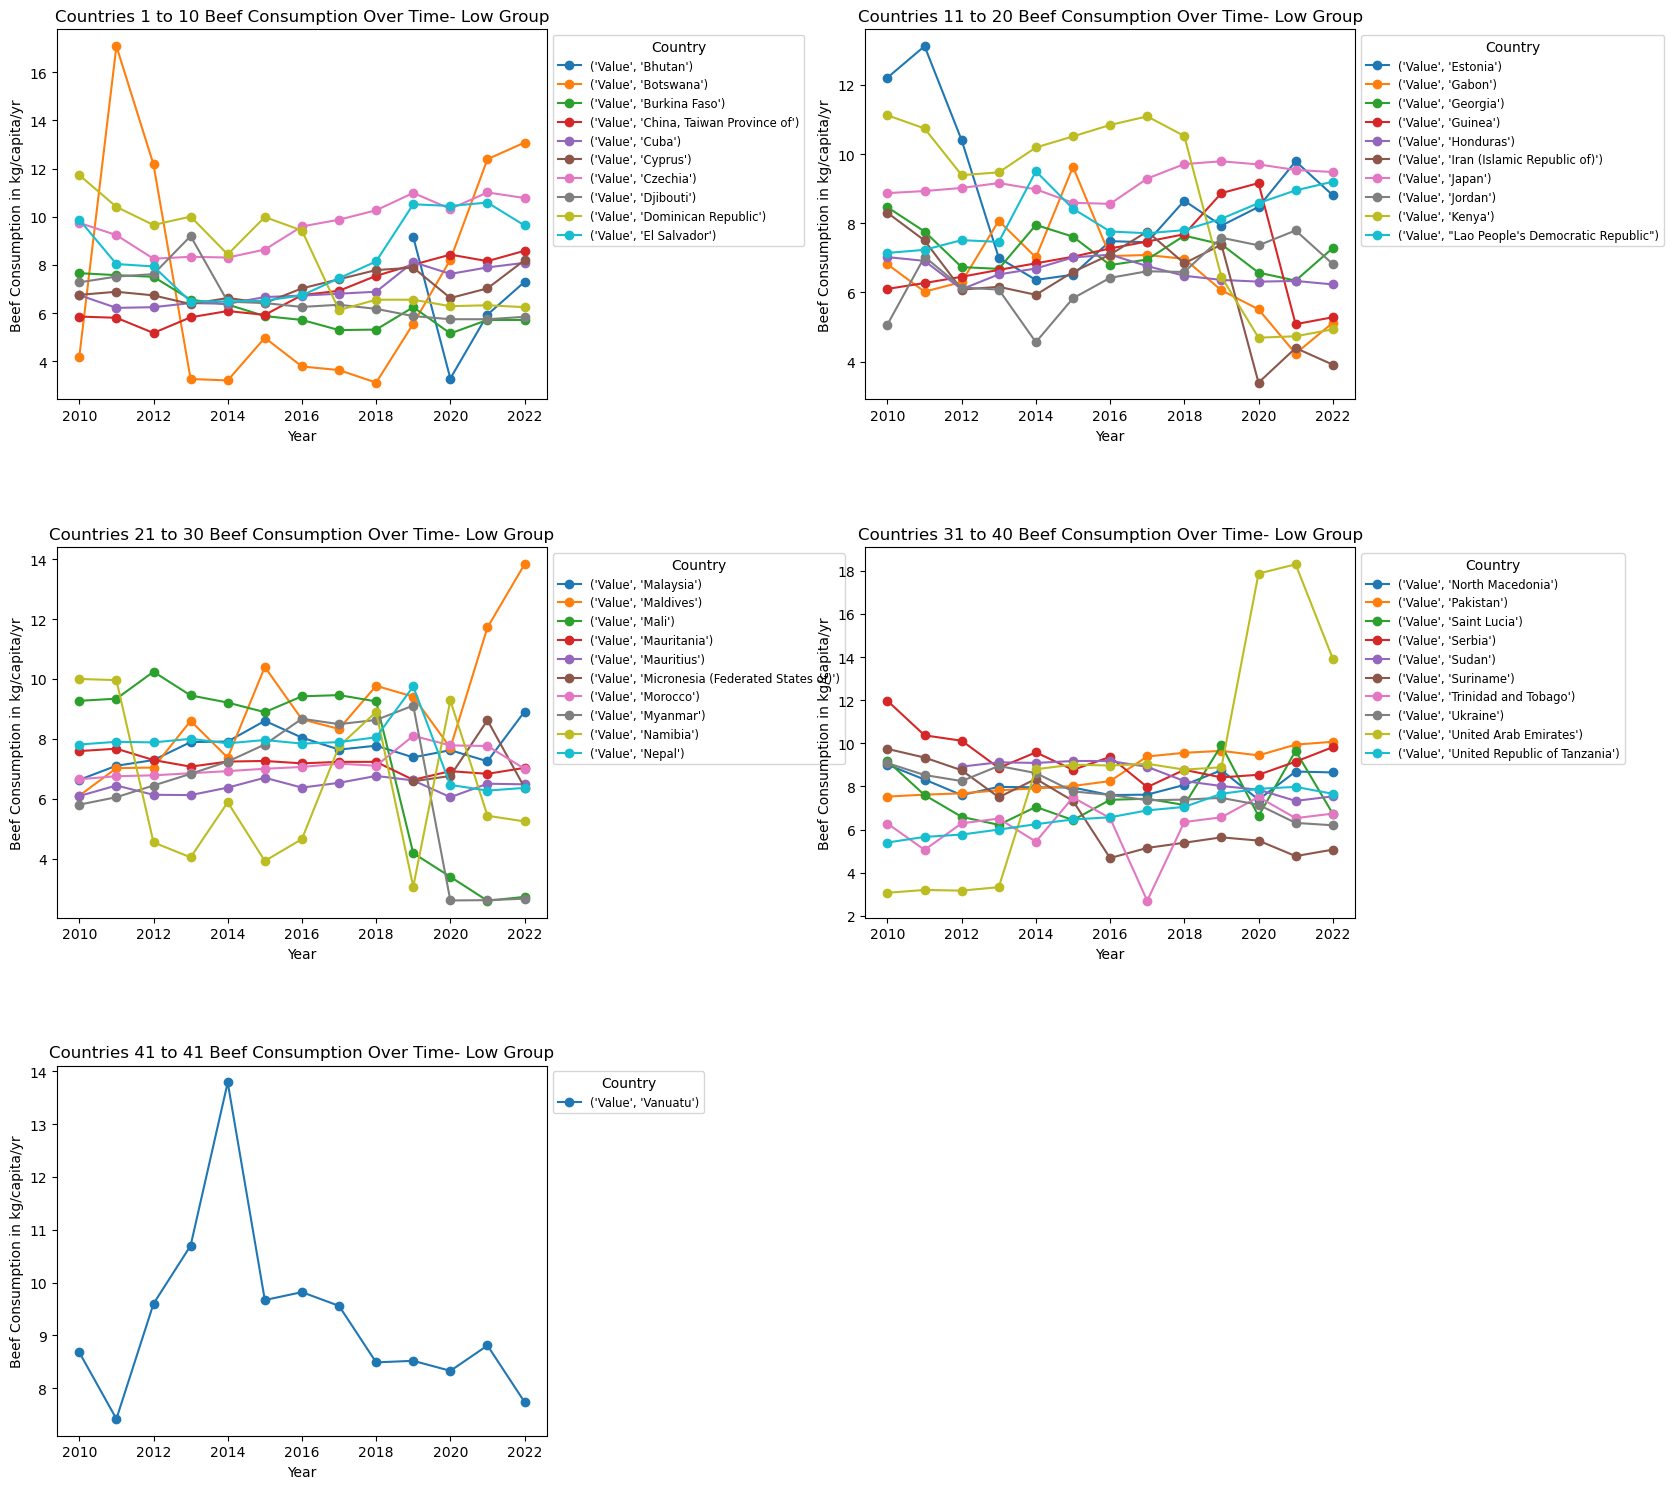

In [42]:
countries = dfG2.columns  
#data = {country: [i * j for j in range(1, len(years) + 1)] for i, country in enumerate(countries, 1)}

# How many rows and columns for subplots do I need?
num_plots = len(countries) // 10 + (1 if len(countries) % 10 != 0 else 0)
rows = (num_plots // 2) + (num_plots % 2)
cols = 2

# Increased figure size
fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 5))
axes = axes.flatten()

for i in range(0, len(countries), 10):
    selected_countries = countries[i:i+10]
    ax = axes[i // 10]  # Select the correct subplot ??
    
    for country in selected_countries:
        ax.plot(dfG2.index, dfG2[country], marker="o", label=country)
        
    ax.legend(title='Country', bbox_to_anchor=(1.001, 1), loc='upper left', fontsize='small')
    ax.set_title(f'Countries {i+1} to {min(i+10, len(countries))} Beef Consumption Over Time- Low Group')
    ax.set_xlabel('Year')
    ax.set_ylabel('Beef Consumption in kg/capita/yr')

# Hide any unused subplots
for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.subplots_adjust(right=0.85, hspace=0.4, wspace=0.65)  # Adjust right, horizontal, and vertical space
plt.show()


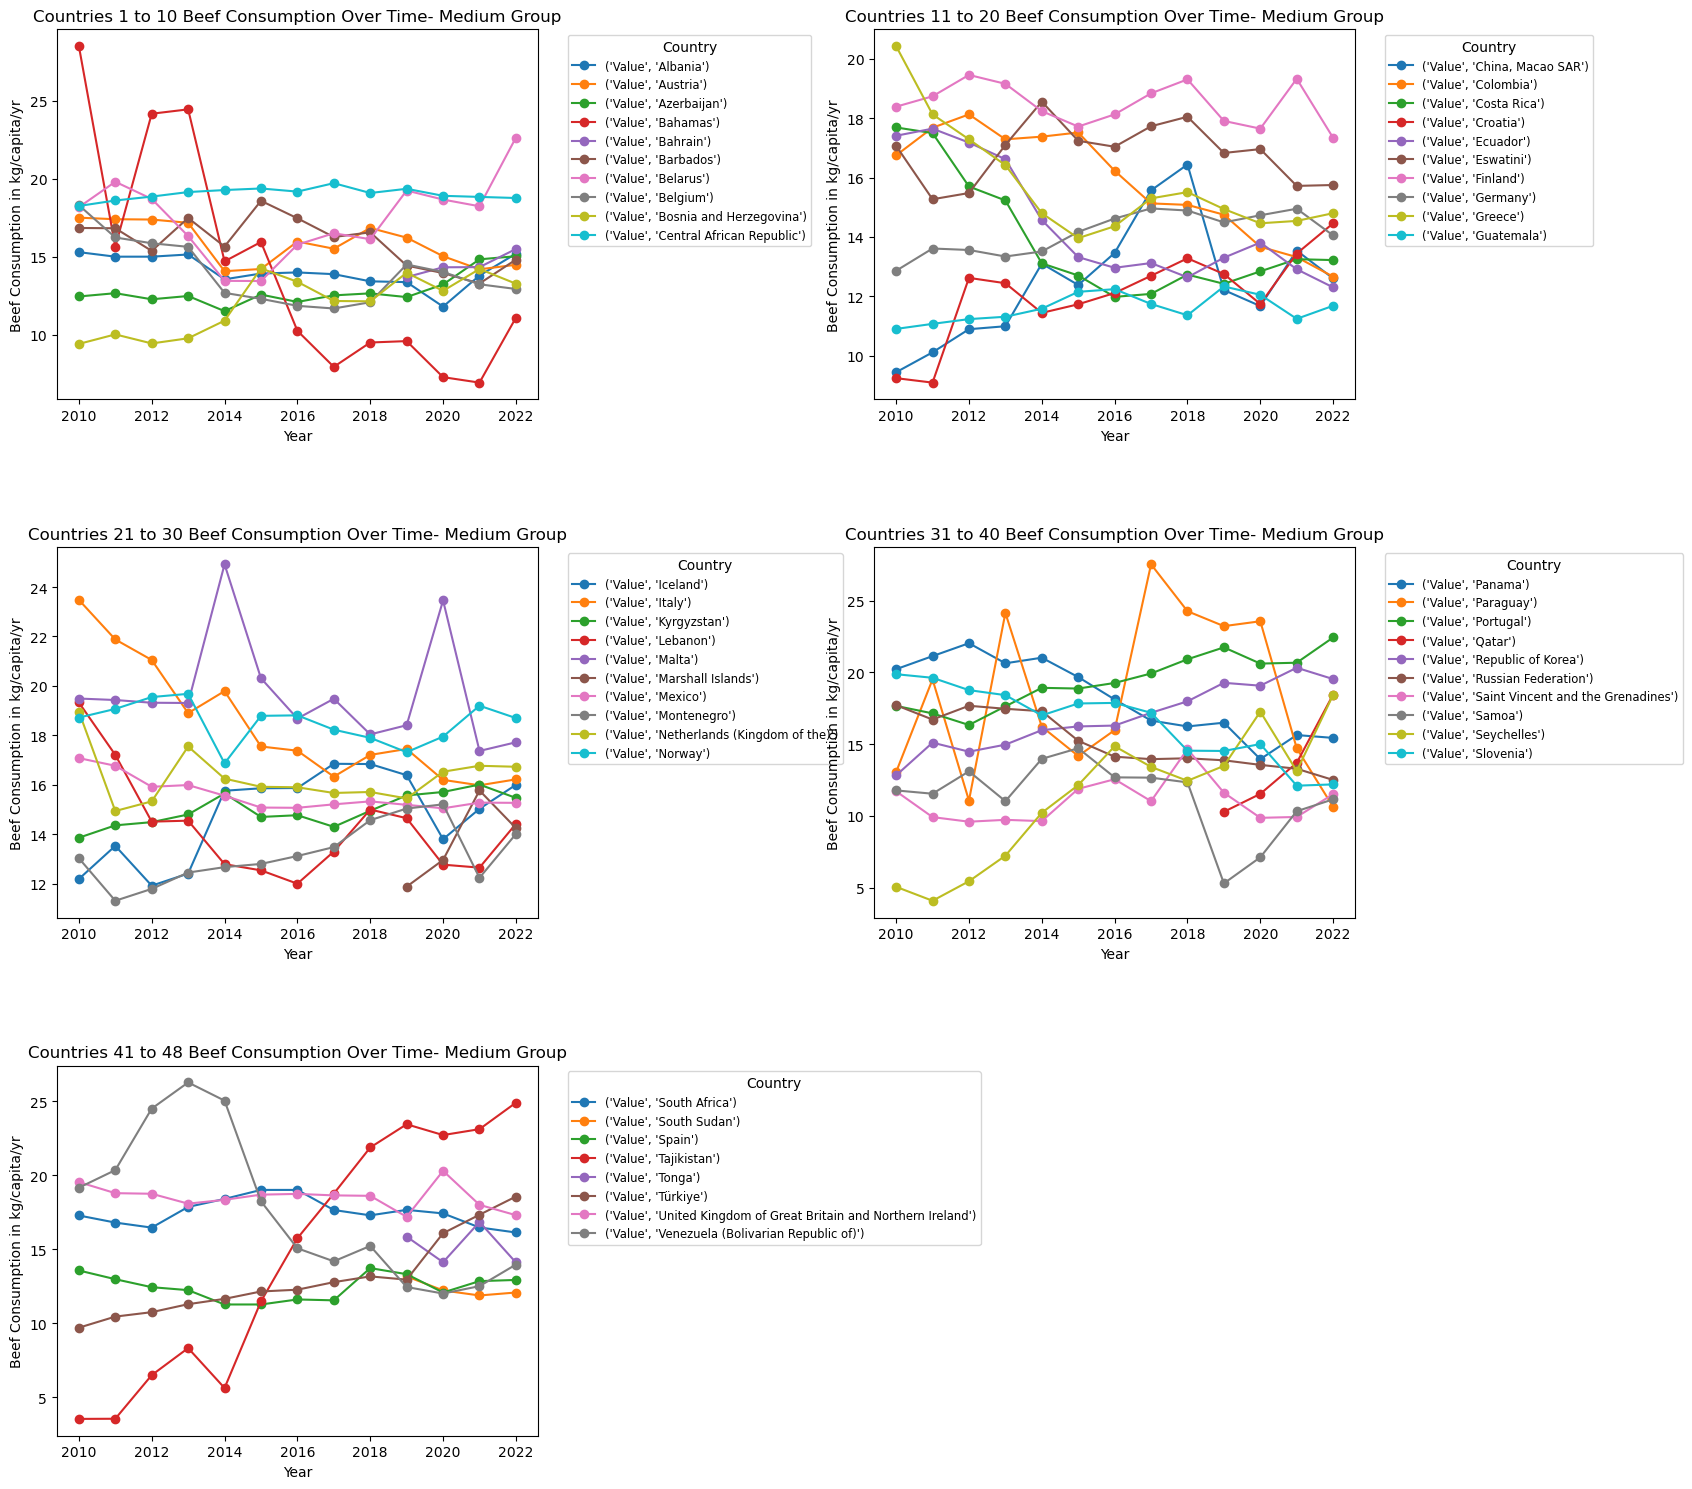

In [44]:
countries = dfG3.columns  
#data = {country: [i * j for j in range(1, len(years) + 1)] for i, country in enumerate(countries, 1)}

# How many rows and columns for subplots do I need?
num_plots = len(countries) // 10 + (1 if len(countries) % 10 != 0 else 0)
rows = (num_plots // 2) + (num_plots % 2)
cols = 2

# Increased figure size
fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 5))
axes = axes.flatten()

for i in range(0, len(countries), 10):
    selected_countries = countries[i:i+10]
    ax = axes[i // 10]  # Select the correct subplot ??
    
    for country in selected_countries:
        ax.plot(dfG3.index, dfG3[country], marker="o", label=country)
        
    ax.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
    ax.set_title(f'Countries {i+1} to {min(i+10, len(countries))} Beef Consumption Over Time- Medium Group')
    ax.set_xlabel('Year')
    ax.set_ylabel('Beef Consumption in kg/capita/yr')

# Hide any unused subplots
for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.subplots_adjust(right=0.85, hspace=0.4, wspace=0.7)  # Adjust right, horizontal, and vertical space
plt.show()


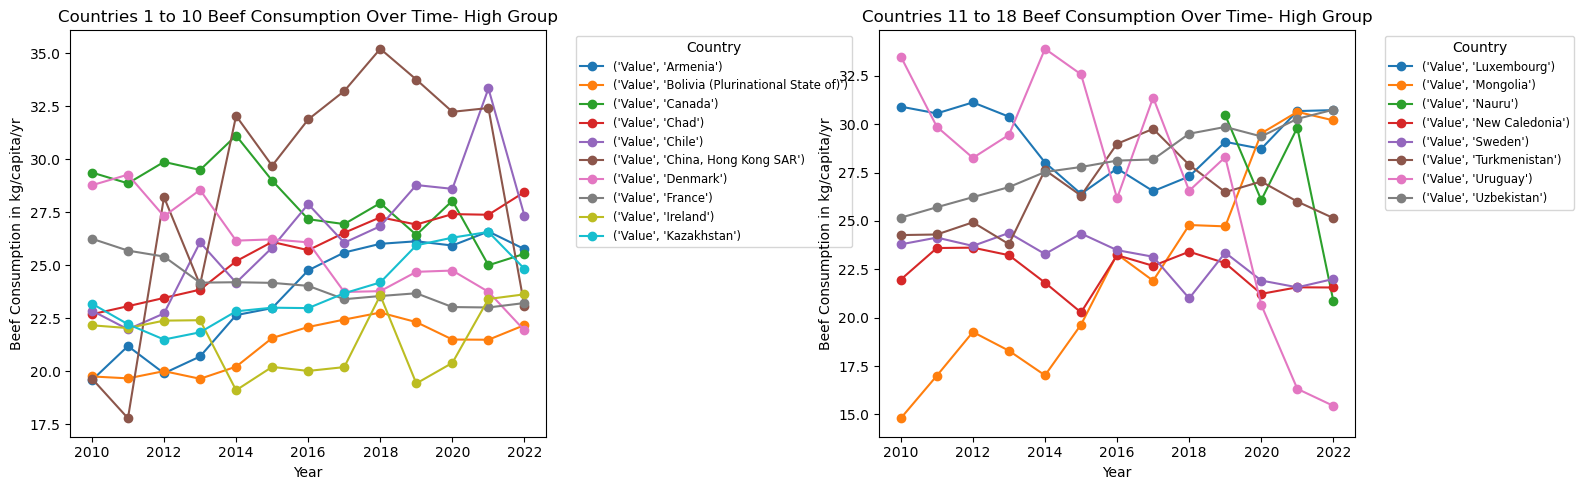

In [46]:
countries = dfG4.columns  
#data = {country: [i * j for j in range(1, len(years) + 1)] for i, country in enumerate(countries, 1)}

# How many rows and columns for subplots do I need?
num_plots = len(countries) // 10 + (1 if len(countries) % 10 != 0 else 0)
rows = (num_plots // 2) + (num_plots % 2)
cols = 2

# Increased figure size
fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 5))
axes = axes.flatten()

for i in range(0, len(countries), 10):
    selected_countries = countries[i:i+10]
    ax = axes[i // 10]  # Select the correct subplot ??
    
    for country in selected_countries:
        ax.plot(dfG4.index, dfG4[country], marker="o", label=country)
        
    ax.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
    ax.set_title(f'Countries {i+1} to {min(i+10, len(countries))} Beef Consumption Over Time- High Group')
    ax.set_xlabel('Year')
    ax.set_ylabel('Beef Consumption in kg/capita/yr')

# Hide any unused subplots
for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.subplots_adjust(right=0.85, hspace=0.4, wspace=0.7)  # Adjust right, horizontal, and vertical space
plt.show()

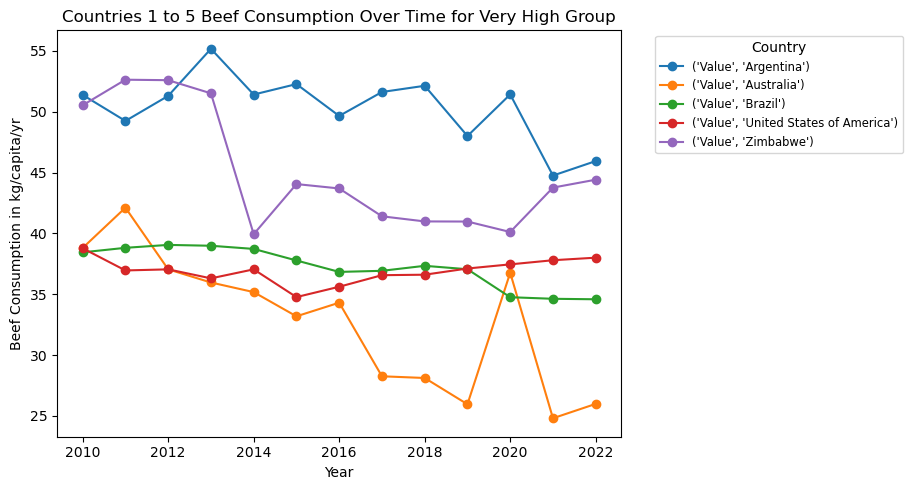

In [48]:
countries = dfG5.columns  
#data = {country: [i * j for j in range(1, len(years) + 1)] for i, country in enumerate(countries, 1)}

# How many rows and columns for subplots do I need?
num_plots = len(countries) // 10 + (1 if len(countries) % 10 != 0 else 0)
rows = (num_plots // 2) + (num_plots % 2)
cols = 2

# Increased figure size
fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 5))
axes = axes.flatten()

for i in range(0, len(countries), 10):
    selected_countries = countries[i:i+10]
    ax = axes[i // 10]  # Select the correct subplot ??
    
    for country in selected_countries:
        ax.plot(dfG5.index, dfG5[country], marker="o", label=country)
        
    ax.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
    ax.set_title(f'Countries {i+1} to {min(i+10, len(countries))} Beef Consumption Over Time for Very High Group')
    ax.set_xlabel('Year')
    ax.set_ylabel('Beef Consumption in kg/capita/yr')

# Hide any unused subplots
for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.subplots_adjust(right=0.85, hspace=0.4, wspace=0.3)  # Adjust right, horizontal, and vertical space
plt.show()

### 2. Group by income


In [91]:
mean_low_area = np.mean(P1['Value'])
median_low_area = np.median(P1['Value'])

mean_lower_middle_area = np.mean(P2['Value'])
median_lower_middle_area = np.median(P2['Value'])

mean_upper_middle_income_area = np.mean(P3['Value'])
median_upper_middle_income_area = np.median(P3['Value'])

mean_high_income_area =  np.mean(P4['Value'])
median_high_income_area =  np.median(P4['Value'])

In [93]:
mean_low_area,mean_lower_middle_area,mean_upper_middle_income_area, mean_high_income_area

(5.219054545454545, 7.149092526690392, 11.898073701842545, 15.6891974317817)

In [95]:
median_low_area,median_lower_middle_area,median_upper_middle_income_area, median_high_income_area

(3.21, 5.275, 9.34, 15.03)

#### Quick Statistics regarding consumption of each income group:

##### Low income:

mean: 5.2

median: 3.21

##### Lower middle income:

mean: 7.1

median: 5.25

##### Upper middle income:

mean: 11.9

median: 9.34

##### High income:

mean: 15.7

median: 15.03


https://datacatalog.worldbank.org/search/dataset/0037712/World-Development-Indicators

In [56]:
df3 = pd.read_csv('WDICountry.csv')
df3_shortened = df3[['Country Code', 'Short Name','Income Group']]

In [58]:
df3['Income Group'].unique()

array(['High income', nan, 'Low income', 'Lower middle income',
       'Upper middle income'], dtype=object)

In [60]:
#df3_shortened[df3_shortened['Income Group'].isna()]

Dropped NaN values since all these values appear in grouped countries/organizations.

In [63]:
df3_shortened = df3_shortened.dropna()
df3_shortened

,Country Code,Short Name,Income Group
0,ABW,Aruba,High income
2,AFG,Afghanistan,Low income
4,AGO,Angola,Lower middle income
5,ALB,Albania,Upper middle income
6,AND,Andorra,High income
...,...,...,...
260,XKX,Kosovo,Upper middle income
261,YEM,Yemen,Low income
262,ZAF,South Africa,Upper middle income
263,ZMB,Zambia,Lower middle income


In [65]:
countries_df3 = set(df3_shortened['Short Name'].values)
countries_df2 = set(df_area_2['Area'].values)

countries_not_in_df2 = countries_df3 - countries_df2

In [67]:
low_income = df3_shortened[df3_shortened['Income Group'] == 'Low income']
lower_middle_income = df3_shortened[df3_shortened['Income Group'] == 'Lower middle income']
upper_middle_income = df3_shortened[df3_shortened['Income Group'] == 'Upper middle income']
high_income = df3_shortened[df3_shortened['Income Group'] == 'High income']
high_income['Short Name'] 

0                       Aruba
6                     Andorra
8        United Arab Emirates
11             American Samoa
12        Antigua and Barbuda
                ...          
241       Trinidad and Tobago
249                   Uruguay
250             United States
254    British Virgin Islands
255            Virgin Islands
Name: Short Name, Length: 85, dtype: object

In [69]:
P1 = df_shortened_2[df_shortened_2['Area'].isin(low_income['Short Name'])]
P2 = df_shortened_2[df_shortened_2['Area'].isin(lower_middle_income['Short Name'])]
P3 = df_shortened_2[df_shortened_2['Area'].isin(upper_middle_income['Short Name'])]
P4 = df_shortened_2[df_shortened_2['Area'].isin(high_income['Short Name'])]

In [71]:
mean_low_area = np.mean(P1['Value'])
mean_lower_middle_area = np.mean(P2['Value'])
upper_middle_income_area = np.mean(P3['Value'])
high_income_area =  np.mean(P4['Value'])

In [73]:
dfP1 = P1.pivot_table(index=['Year'], columns = ['Area'],
                       values=['Value'], aggfunc = 'mean')
dfP2 = P2.pivot_table(index=['Year'], columns = ['Area'],
                       values=['Value'], aggfunc = 'mean')
dfP3 = P3.pivot_table(index=['Year'], columns = ['Area'],
                       values=['Value'], aggfunc = 'mean')
dfP4 = P4.pivot_table(index=['Year'], columns = ['Area'],
                       values=['Value'], aggfunc = 'mean')

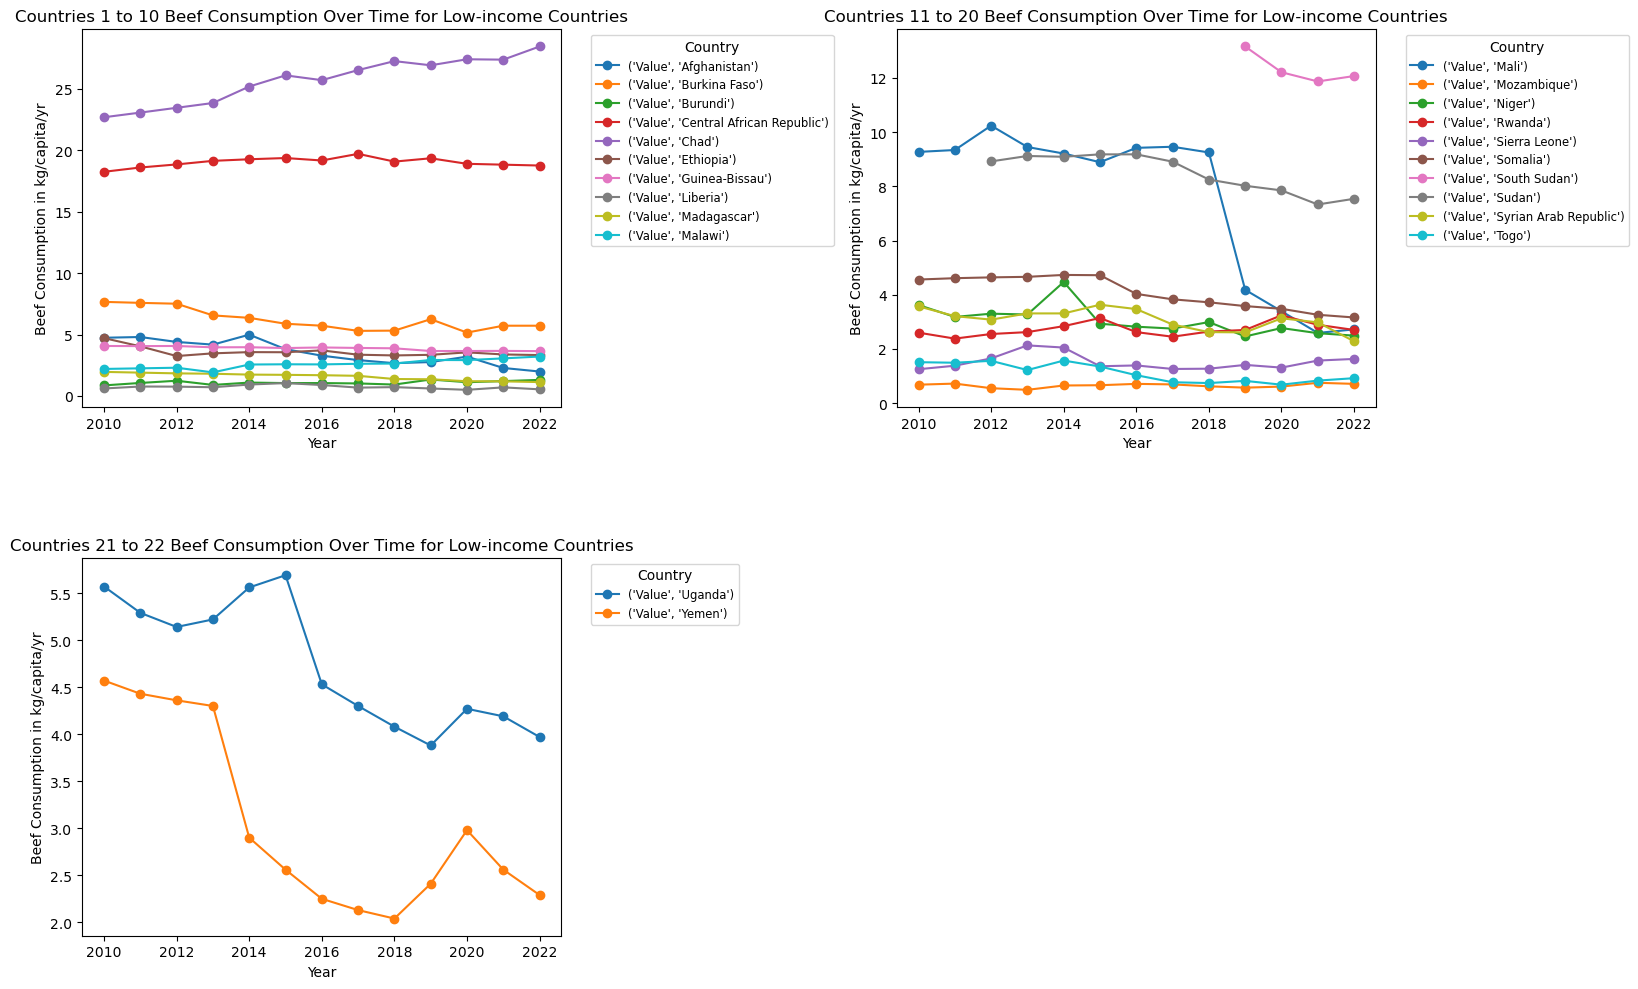

In [75]:
countries = dfP1.columns  
num_plots = len(countries) // 10 + (1 if len(countries) % 10 != 0 else 0)
rows = (num_plots // 2) + (num_plots % 2)
cols = 2

# Increased figure size
fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 5))
axes = axes.flatten()

for i in range(0, len(countries), 10):
    selected_countries = countries[i:i+10]
    ax = axes[i // 10]  # Select the correct subplot ??
    
    for country in selected_countries:
        ax.plot(dfP1.index, dfP1[country], marker="o", label=country)
        
    ax.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
    ax.set_title(f'Countries {i+1} to {min(i+10, len(countries))} Beef Consumption Over Time for Low-income Countries')
    ax.set_xlabel('Year')
    ax.set_ylabel('Beef Consumption in kg/capita/yr')

# Hide any unused subplots
for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.subplots_adjust(right=0.85, hspace=0.4, wspace=0.7)  # Adjust right, horizontal, and vertical space
plt.show()

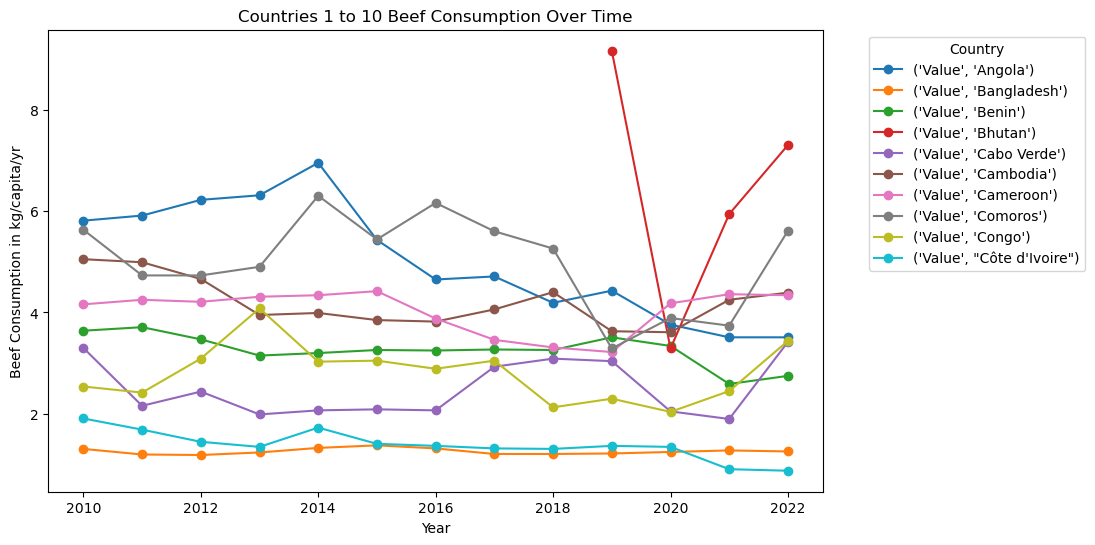

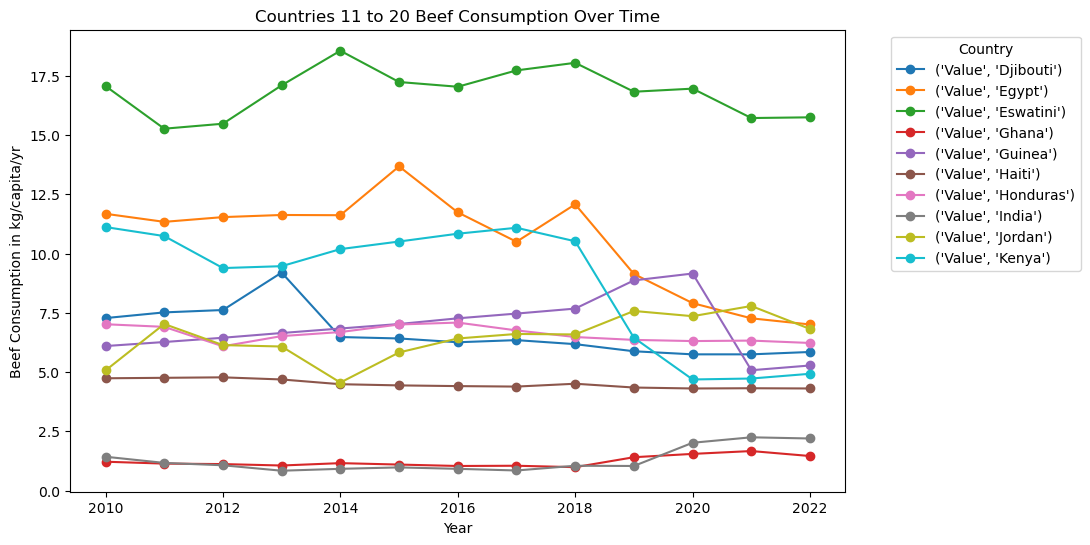

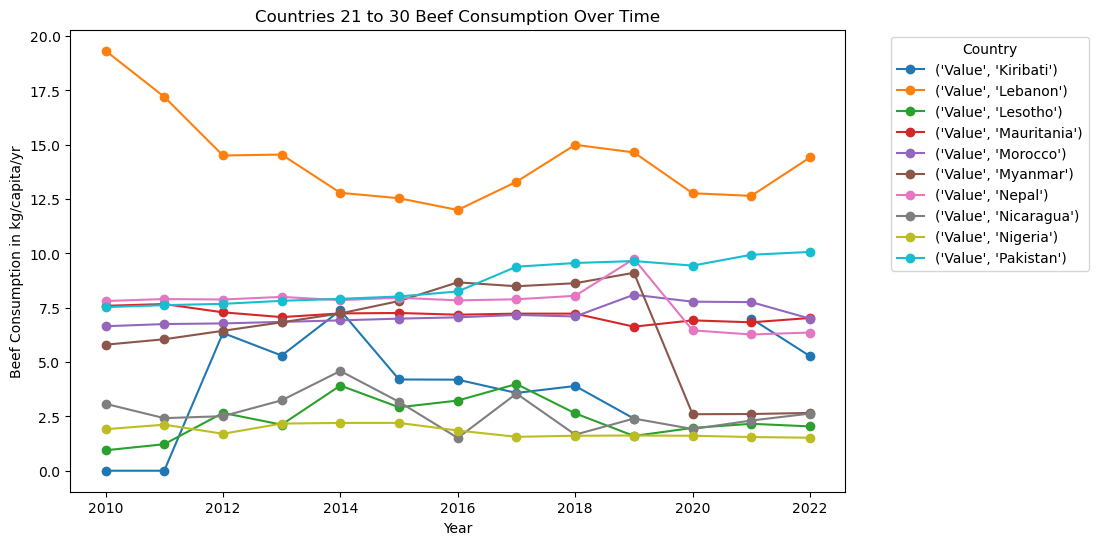

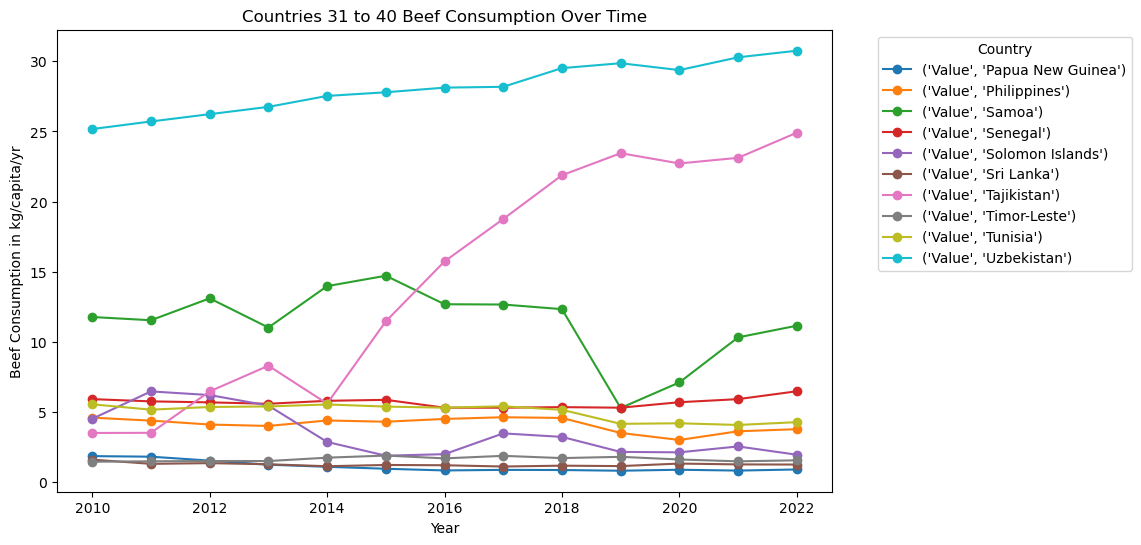

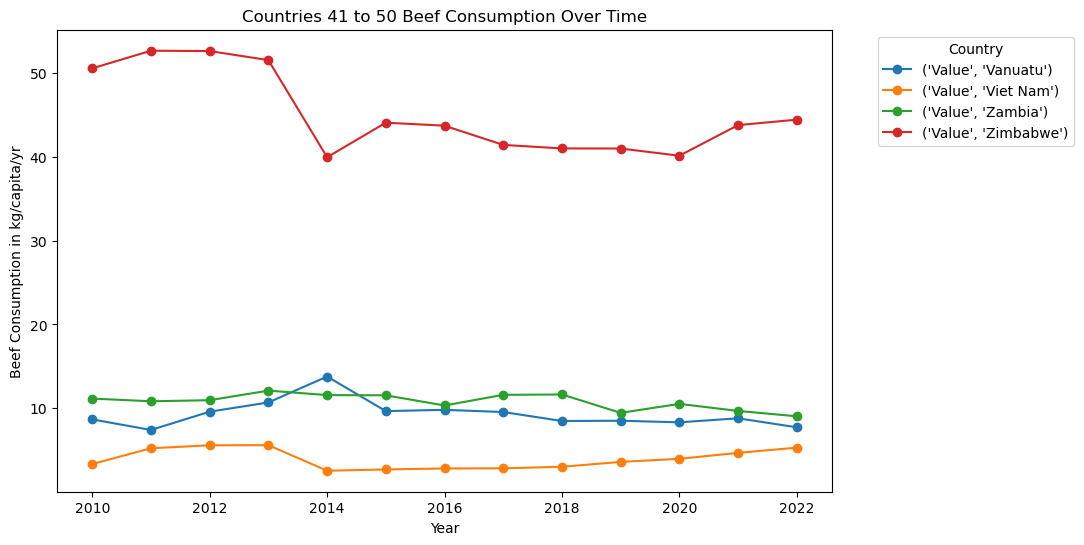

In [77]:
countries = dfP2.columns  
for i in range(0, len(countries), 10):
   
    selected_countries = countries[i:i+10] # Easier to identify the countries
    
    plt.figure(figsize=(10, 6))
    
   
    for country in selected_countries:
        plt.plot(dfP2.index, dfP2[country], marker="o", label=country)
   
    plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.title(f'Countries {i+1} to {i+10} Beef Consumption Over Time')
    plt.xlabel('Year')
    plt.ylabel('Beef Consumption in kg/capita/yr')

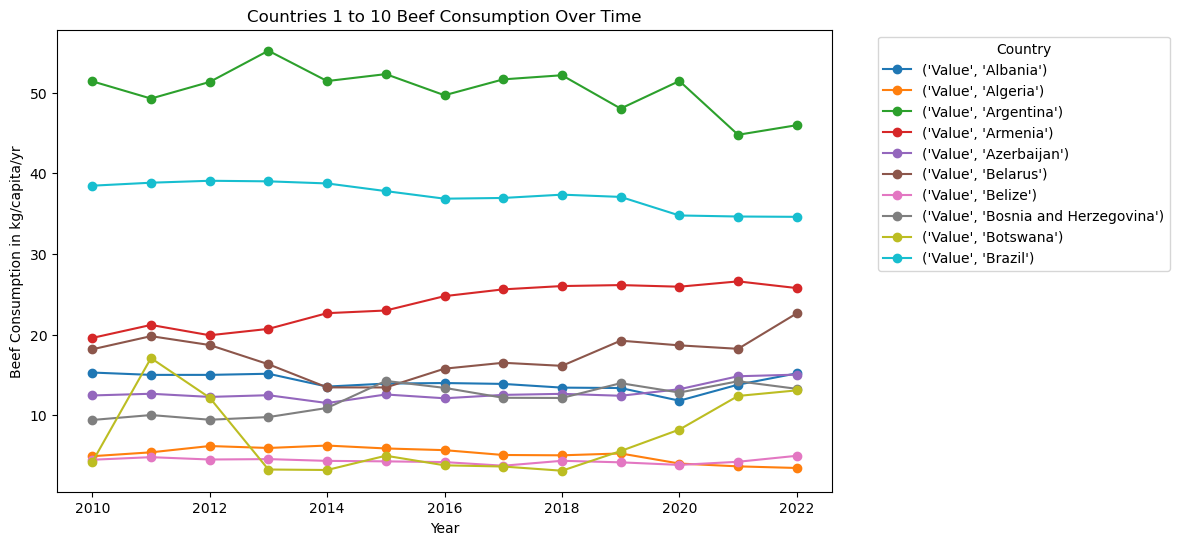

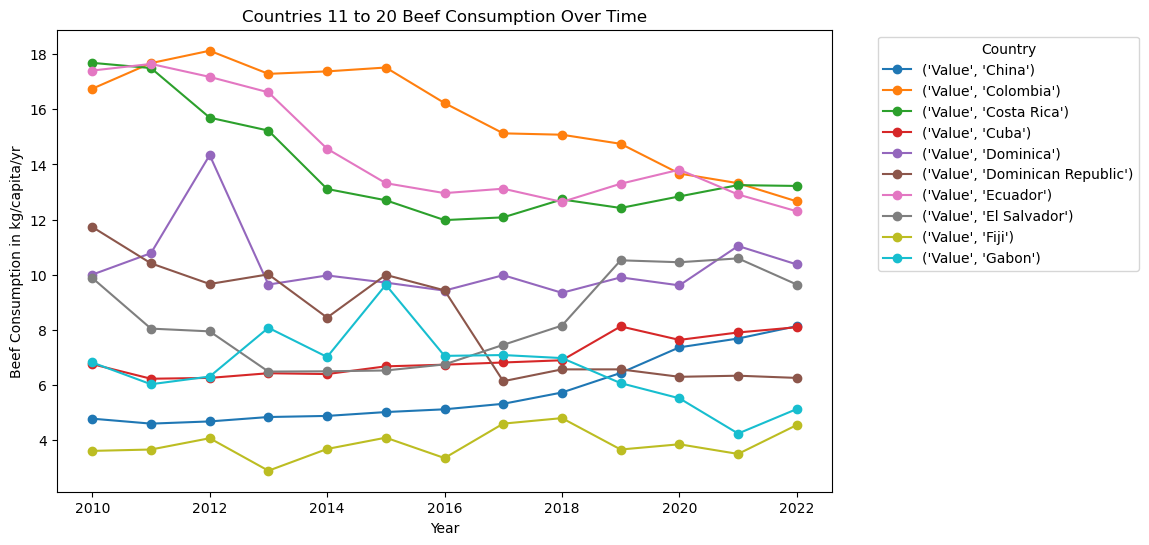

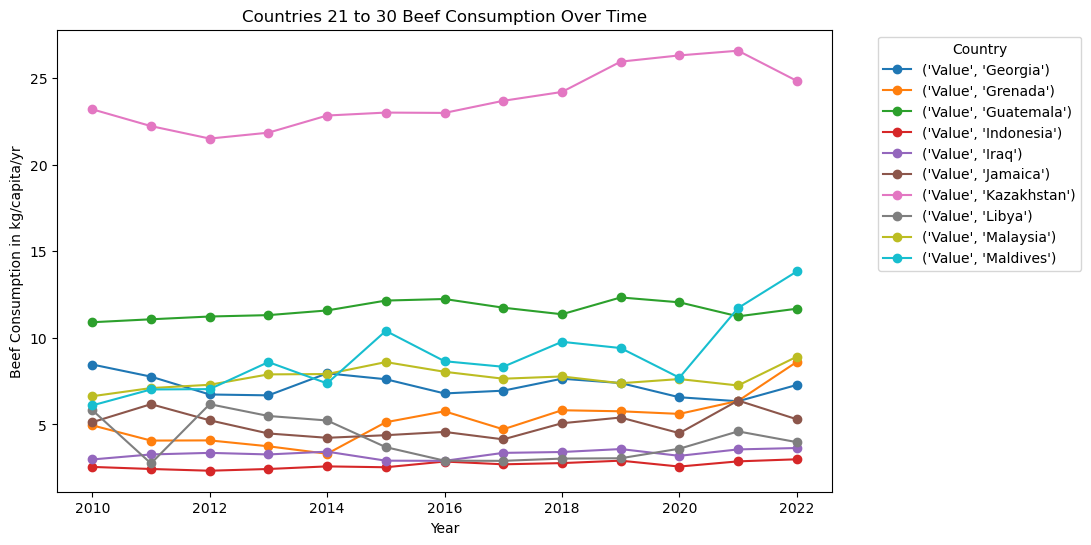

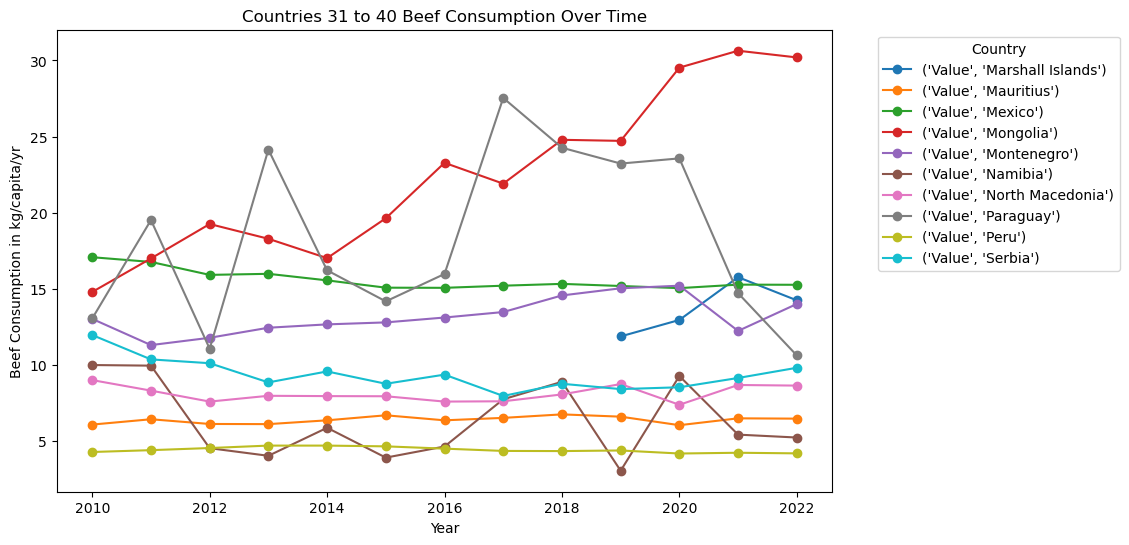

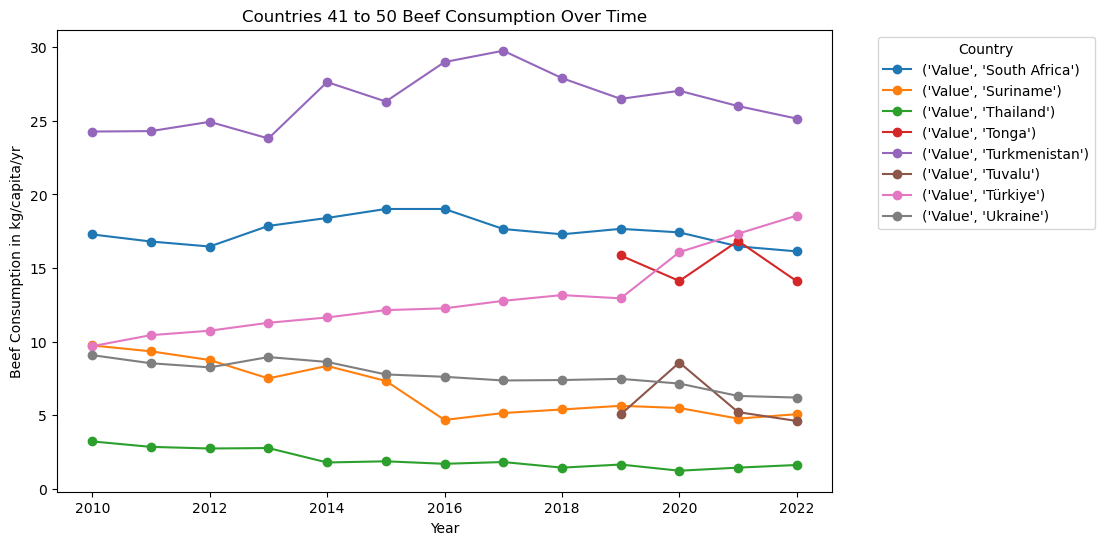

In [78]:
countries = dfP3.columns  
for i in range(0, len(countries), 10):
   
    selected_countries = countries[i:i+10] # Easier to identify the countries
    
    plt.figure(figsize=(10, 6))
    
   
    for country in selected_countries:
        plt.plot(dfP3.index, dfP3[country], marker="o", label=country)
        
   
    plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.title(f'Countries {i+1} to {i+10} Beef Consumption Over Time')
    plt.xlabel('Year')
    plt.ylabel('Beef Consumption in kg/capita/yr')

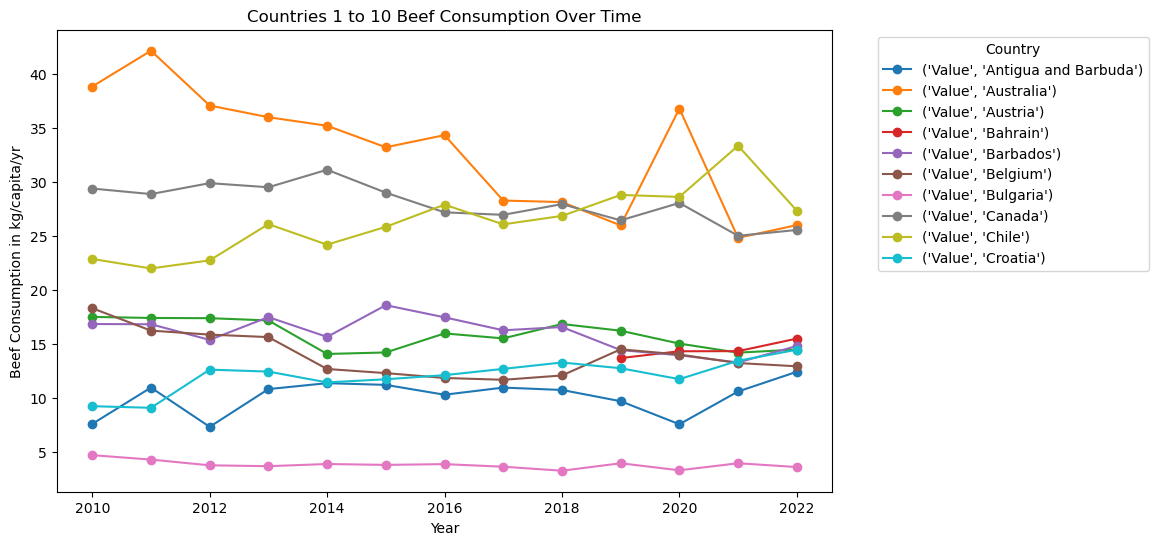

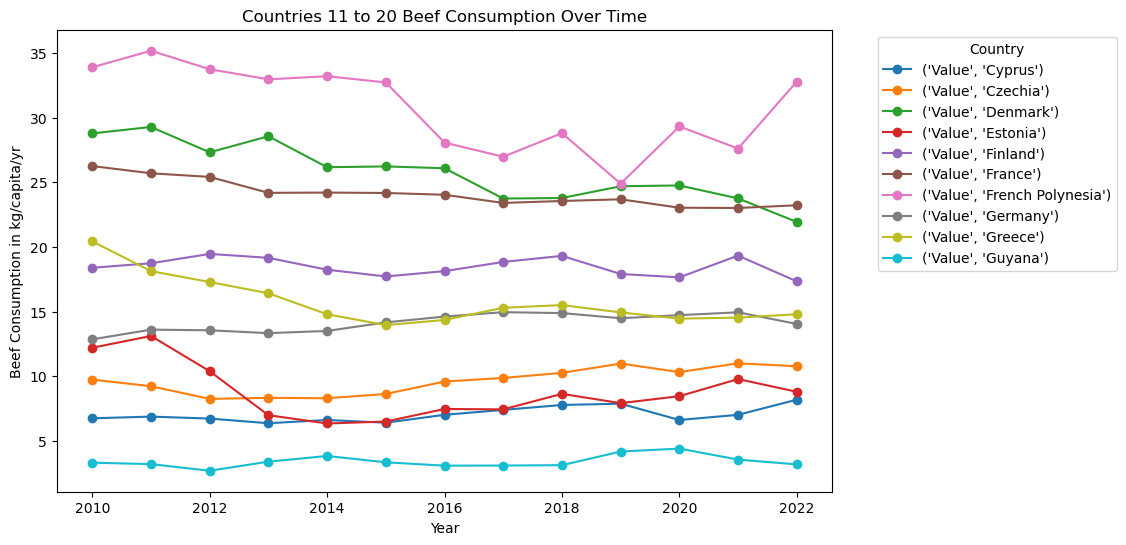

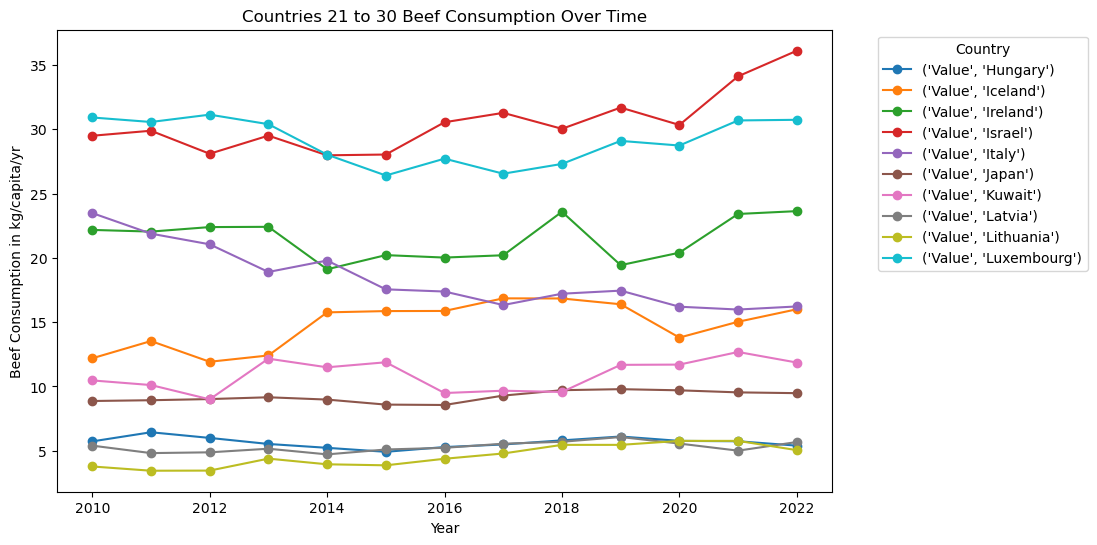

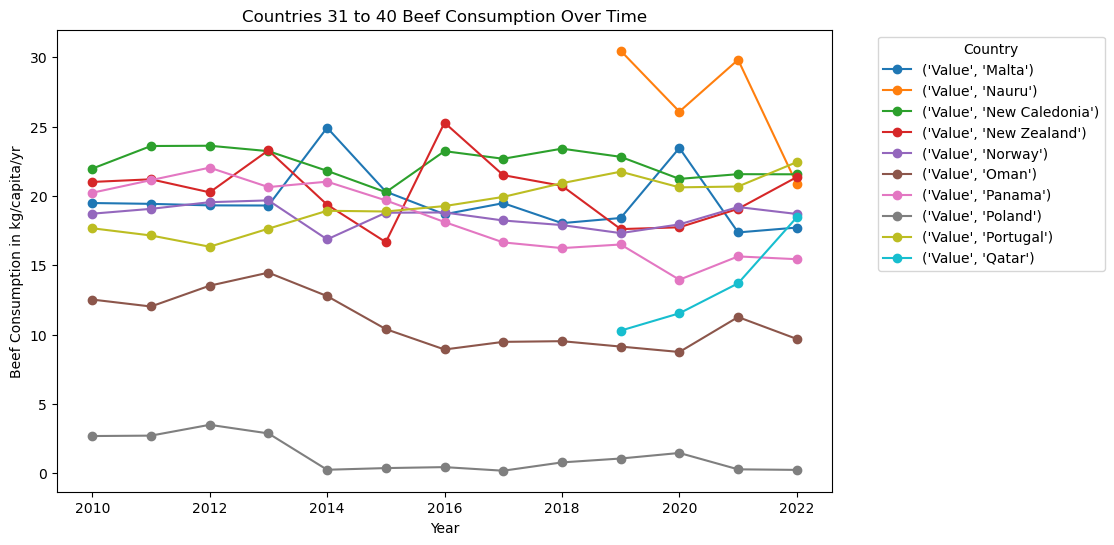

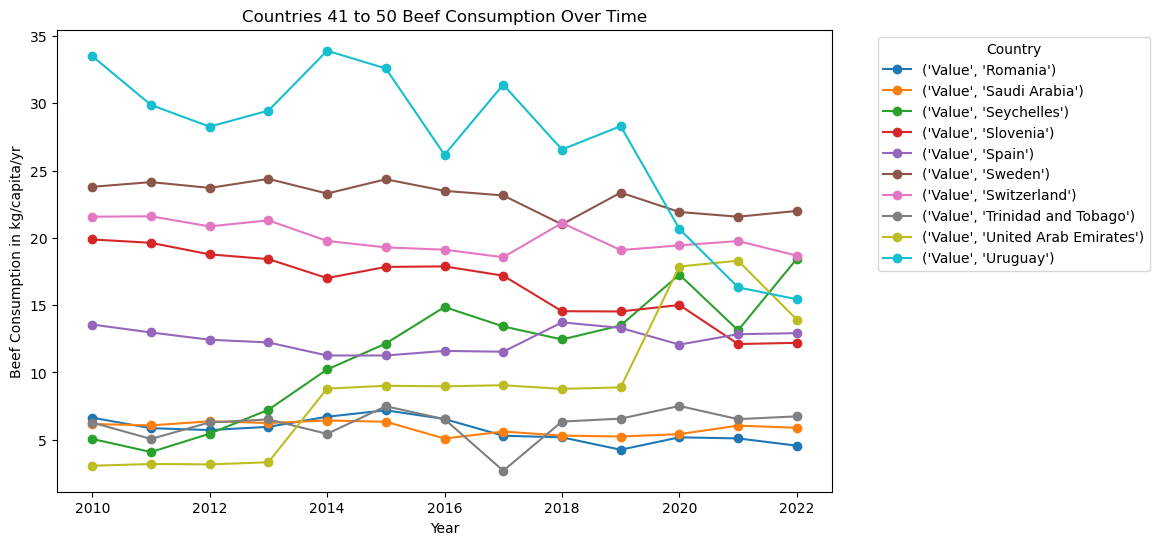

In [80]:
countries = dfP4.columns  
for i in range(0, len(countries), 10):
   
    selected_countries = countries[i:i+10] # Easier to identify the countries
    
    plt.figure(figsize=(10, 6))
    
   
    for country in selected_countries:
        plt.plot(dfP4.index, dfP4[country], marker="o", label=country)
        
   
    plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.title(f'Countries {i+1} to {i+10} Beef Consumption Over Time')
    plt.xlabel('Year')
    plt.ylabel('Beef Consumption in kg/capita/yr')

### 3. Group by land area

In [83]:
df3.columns

Index(['Country Code', 'Short Name', 'Table Name', 'Long Name', '2-alpha code',
       'Currency Unit', 'Special Notes', 'Region', 'Income Group', 'WB-2 code',
       'National accounts base year', 'National accounts reference year',
       'SNA price valuation', 'Lending category', 'Other groups',
       'System of National Accounts', 'Alternative conversion factor',
       'PPP survey year', 'Balance of Payments Manual in use',
       'External debt Reporting status', 'System of trade',
       'Government Accounting concept', 'IMF data dissemination standard',
       'Latest population census', 'Latest household survey',
       'Source of most recent Income and expenditure data',
       'Vital registration complete', 'Latest agricultural census',
       'Latest industrial data', 'Latest trade data',
       'Latest water withdrawal data'],
      dtype='object')

In [84]:
df3['Latest agricultural census']

0       NaN
1       NaN
2       NaN
3       NaN
4       NaN
       ... 
260    2014
261     NaN
262    2007
263     NaN
264     NaN
Name: Latest agricultural census, Length: 265, dtype: object

### 4. Can we find price data on Beef? Global beef price index for beef, or something like that?


##### Beef Price over time in BRL/15 kg 
Instituion: Trading Economics
https://tradingeconomics.com/commodity/beef

USA Meat Price:
https://www.ers.usda.gov/data-products/meat-price-spreads/ 